In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

In [76]:
#The XGBoost Predictive Pipeline Code

In [77]:
# 1. Load and unify the marketplace data
df_orders = pd.read_csv('glovo_orders_1.csv')
df_restaurants = pd.read_csv('glovo_restaurants.csv')
df_couriers = pd.read_csv('glovo_couriers.csv')
df_restaurants.head()

,restaurant_id,restaurant_name,neighborhood,cuisine_type,avg_prep_time_baseline
0,REST_001,Partner Kitchen1,Gòtic,Mexican,24
1,REST_002,Partner Kitchen2,Poblenou,Mexican,14
2,REST_003,Partner Kitchen3,Gràcia,Pizza,16
3,REST_004,Partner Kitchen4,Poblenou,Pizza,17
4,REST_005,Partner Kitchen5,Sarrià,Healthy/Salads,17


In [78]:
#Convert order timestamps to real datetime objects
df_orders['order_placed_at'] = pd.to_datetime(df_orders['order_placed_at'])

#Feature Engineering: Extract the hour integer from the timestamp string
df_orders['hour_of_day'] = df_orders['order_placed_at'].dt.hour

#Filter out canceled orders so the model only learns from successfully delivered cycles
df_delivered = df_orders[df_orders['order_status'] == 'Delivered'].copy()

#Left-join dimensional context (cuisine from restaurants, vehicle from couriers) onto the orders fact records
df_ml = df_delivered.merge(df_restaurants[['restaurant_id', 'cuisine_type']], on='restaurant_id', how='left')
df_ml = df_ml.merge(df_couriers[['courier_id', 'vehicle_type']], on='courier_id', how='left')


df_ml.head()


,order_id,order_placed_at,restaurant_id,courier_id,delivery_neighborhood,basket_value_euros,delivery_fee_euros,commission_euros,prep_time_minutes,courier_wait_minutes,travel_time_minutes,is_raining,order_status,hour_of_day,cuisine_type,vehicle_type
0,GLV_000001,2026-06-03 10:13:00,REST_018,COUR_004,Gòtic,24.50,3.52,5.39,15,1,11,0,Delivered,10,Burgers,Moto
1,GLV_000002,2026-06-02 12:18:00,REST_016,COUR_032,Poblenou,44.56,2.37,9.80,15,9,8,0,Delivered,12,Burgers,Moto
2,GLV_000003,2026-06-05 16:21:00,REST_028,COUR_130,Gòtic,62.96,1.95,13.85,21,0,8,0,Delivered,16,Tacos,Moto
3,GLV_000004,2026-06-03 20:16:00,REST_009,COUR_016,Eixample,62.80,3.78,13.82,25,7,21,1,Delivered,20,Burgers,Electric Scooter
4,GLV_000005,2026-06-03 20:27:00,REST_047,COUR_021,Sants,49.12,3.54,10.81,31,11,27,1,Delivered,20,Pizza,Bicycle


--- MODEL PERFORMANCE METRICS ---
Mean Absolute Error (MAE): 6.21 Minutes
R-squared (R²) Score: -0.09
---------------------------------
Total Labels Generated: 41
Total Model Importances: 41


/var/folders/n7/8rc6wlyx2xn35xn609v117t80000gn/T/ipykernel_97829/2300285975.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis')


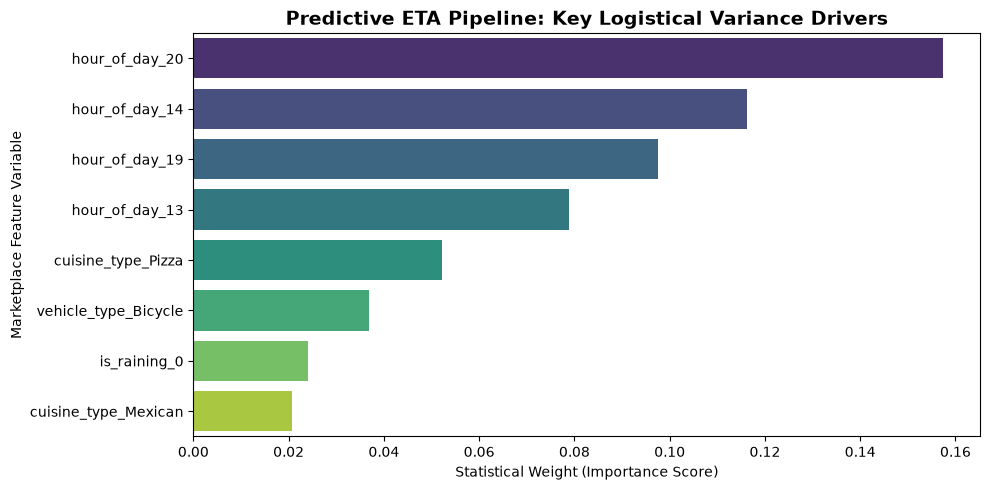

In [79]:
# 2. Define features and the target variable

#Target: Total Delivery Cycle Time (Preparation + Wait + Transit)
df_ml['total_delivery_time_target'] = df_ml['prep_time_minutes'] + df_ml['travel_time_minutes']

features = ['delivery_neighborhood', 'cuisine_type', 'vehicle_type', 'hour_of_day', 'is_raining']
X = df_ml[features]
y = df_ml['total_delivery_time_target']

# 3. The Validation framework (train / test split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Preprocessing via one-hot encoding
# XGBoost operates exclusively on numbers; we must expand text strings into binary columns

categorical_features = ['delivery_neighborhood', 'cuisine_type', 'vehicle_type', 'hour_of_day', 'is_raining']
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)   

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)


# 5. Train the XGBoost model
model = XGBRegressor(n_estimators=100, learning_rate=0.8, max_depth=5, random_state=42)
model.fit(X_train_encoded, y_train)

# 6. Model evauation metrics
predicitons = model.predict(X_test_encoded)
mae = mean_absolute_error(y_test, predicitons)
r2 = r2_score(y_test, predicitons)

print("--- MODEL PERFORMANCE METRICS ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} Minutes")
print(f"R-squared (R²) Score: {r2:.2f}")
print("---------------------------------")

# 7.Dynamically extract & align features names.
# Get feature names from the transformer safely supporting passthrough columns
all_feature_names = preprocessor.get_feature_names_out()

# Clean up visual noise like 'cat__' or 'remainder__' prefix string flags that scikit-learn adds
all_feature_names = [name.replace('cat__', '').replace('remainder__', '') for name in all_feature_names]

importances = model.feature_importances_

# Verify lengths before creating the DataFrame to ensure alignment
print(f"Total Labels Generated: {len(all_feature_names)}")
print(f"Total Model Importances: {len(importances)}")

df_importance = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False).head(8)

# VISUALIZATION 
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis')
plt.title('Predictive ETA Pipeline: Key Logistical Variance Drivers', fontsize=14, weight='bold')
plt.xlabel('Statistical Weight (Importance Score)')
plt.ylabel('Marketplace Feature Variable')
plt.tight_layout()
plt.savefig('xgboost_feature_importance.png')
plt.show()


In [80]:
#I realized I had left out a massive source of variance: add courier wait time in my model, courier availability and traffic conditions in my simulation.


--- MODEL PERFORMANCE METRICS ---
Mean Absolute Error (MAE): 3.92 Minutes
R-squared (R²) Score: 0.79
---------------------------------



/var/folders/n7/8rc6wlyx2xn35xn609v117t80000gn/T/ipykernel_97829/3973674847.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis')


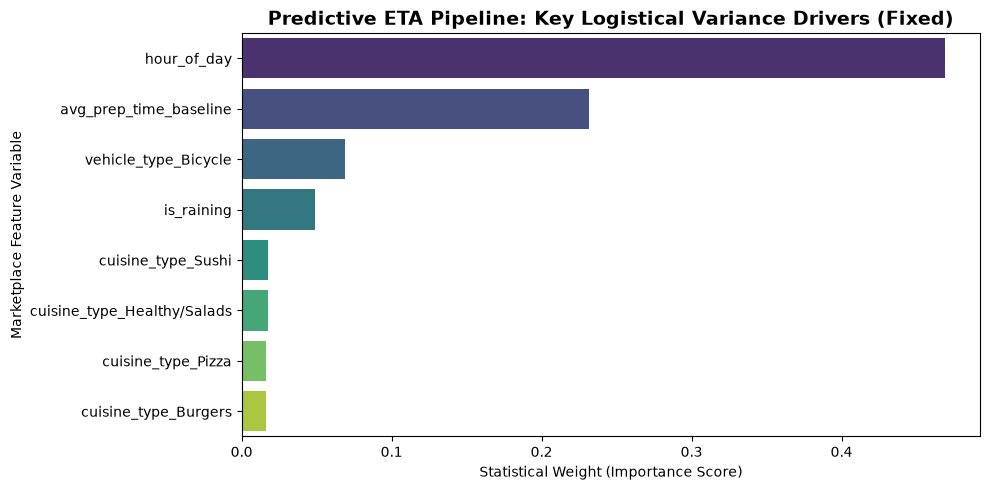

--- ACTUAL VS. PREDICTED DELIVERY TIMES ---
Average True Wait Time (Test Set): 41.64 Minutes
Average Predicted Wait Time:       41.93 Minutes
-------------------------------------------


In [81]:


# --- 1. LOAD AND UNIFY THE MARKETPLACE DATA ---
df_orders = pd.read_csv('glovo_orders_2.csv')
df_restaurants = pd.read_csv('glovo_restaurants.csv')
df_couriers = pd.read_csv('glovo_couriers.csv')

# Convert order timestamps to real datetime objects
df_orders['order_placed_at'] = pd.to_datetime(df_orders['order_placed_at'])

# Feature Engineering: Extract the hour integer from the timestamp string
df_orders['hour_of_day'] = df_orders['order_placed_at'].dt.hour

# Filter out canceled orders so the model only learns from successfully delivered cycles
df_delivered = df_orders[df_orders['order_status'] == 'Delivered'].copy()

# Left-join ALL dimensional context (baseline prep time, cuisine, vehicle type)
df_ml = df_delivered.merge(df_restaurants[['restaurant_id', 'cuisine_type', 'avg_prep_time_baseline']], on='restaurant_id', how='left')
df_ml = df_ml.merge(df_couriers[['courier_id', 'vehicle_type']], on='courier_id', how='left')

# --- 2. DEFINE FEATURES AND THE TARGET VARIABLE ---
# Target: Total Delivery Cycle Time (Prep + Wait + Transit)
df_ml['total_delivery_time_target'] = (
    df_ml['prep_time_minutes'] + 
    df_ml['courier_wait_minutes'] + 
    df_ml['travel_time_minutes']
)

# CRITICAL FIX: Include avg_prep_time_baseline so the model understands individual restaurant speed differences
features = ['delivery_neighborhood', 'cuisine_type', 'vehicle_type', 'hour_of_day', 'is_raining', 'avg_prep_time_baseline']
X = df_ml[features]
y = df_ml['total_delivery_time_target']

# --- 3. THE VALIDATION FRAMEWORK (TRAIN/TEST SPLIT) ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# --- 4. PREPROCESSING VIA ONE-HOT ENCODING ---
categorical_features = ['delivery_neighborhood', 'cuisine_type', 'vehicle_type']
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

# --- 5. TRAIN THE XGBOOST REGRESSOR ---
model = XGBRegressor(n_estimators=150, learning_rate=0.05, max_depth=6, random_state=42)
model.fit(X_train_encoded, y_train)

# --- 6. MODEL EVALUATION METRICS ---
predictions = model.predict(X_test_encoded)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("\n--- MODEL PERFORMANCE METRICS ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} Minutes")
print(f"R-squared (R²) Score: {r2:.2f}")
print("---------------------------------\n")

# --- 7. DYNAMICALLY MAP FEATURE IMPORTANCE ---
# CRITICAL FIX: Use get_feature_names_out() so names match the transformed column index exactly
raw_feature_names = preprocessor.get_feature_names_out()
# Clean up prefixes like "cat__" or "remainder__" for the chart visualization
clean_feature_names = [name.replace('cat__', '').replace('remainder__', '') for name in raw_feature_names]

importances = model.feature_importances_
df_importance = pd.DataFrame({'Feature': clean_feature_names, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False).head(8)

# Plotting the realigned metrics
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis')
plt.title('Predictive ETA Pipeline: Key Logistical Variance Drivers (Fixed)', fontsize=14, weight='bold')
plt.xlabel('Statistical Weight (Importance Score)')
plt.ylabel('Marketplace Feature Variable')
plt.tight_layout()
plt.savefig('xgboost_feature_importance_2.png')
plt.show()

# Calculate the average of the true wait times in our test set
avg_actual_time = y_test.mean()

# Calculate the average of what our XGBoost model predicted
avg_predicted_time = predictions.mean()

print("--- ACTUAL VS. PREDICTED DELIVERY TIMES ---")
print(f"Average True Wait Time (Test Set): {avg_actual_time:.2f} Minutes")
print(f"Average Predicted Wait Time:       {avg_predicted_time:.2f} Minutes")
print("-------------------------------------------")